In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Preprocessing Data

In [2]:
#importing data
df = pd.read_csv("nmibc_data.csv")

#remove histology columns
df = df.drop(columns=[
    "GP Infiltrative",
    "Gp Trabecular",
    "Gp Pseudoglandular",
    "Gp Glandular",
    "Pvh Micropapillary",
    "Pvh Adenocarcinoma",
    "Pvh Smallcell",
    "Pvh Nested",
    "Pvh Glandular",
    "Pvh Sarcomatoid",
    "Pvh Acinar",
    "Pvh Other",
    "Pvh Poorlydifferentiated",
    "Svh Poorlydifferentiated",
    "Svh Adenocarcinoma",
    "Svh Nested",
    "Svh Micropapillary",
    "Svh Sarcomatoid",
    "Svh Other",
    "Svh Glandular",
    "Svh Acinar",
    "Svh Smallcell",
    "Pvh Squamous",
    "Svh Squamous"
])

print(df.columns)
#view data
print(df.head())


#handle missing values
#check which features are missing values
print(df.isnull().sum())

#remove rows with missing values in columns with <5% of total rows missing values ("Sample Grade")
df = df.dropna(subset=["Sample Grade"])

#fill rows with unknown in columns with remaining missing values with "unknown"
df["Specimen Available"] = df["Specimen Available"].fillna("unknown")
df["BCG Instillations"] = df["BCG Instillations"].fillna("unknown")
df["Urothelial Like"] = df["Urothelial Like"].fillna("unknown")

#normalize data?
#format?
#subset data?

Index(['Patient_ID', 'Sample Id', 'Proteomics Id', 'Proteomics Sample',
       'Proteomics Batch', 'Proteomics Set', 'Proteomics Stage',
       'Total Abundance', 'Gene Of Interest', 'Immuno Value', 'TURBT Number',
       'TMA Number', 'Associated CIS', 'Muscularis Propria Present', 'LVI YN',
       'Urothelial Like', 'Sample Stage', 'Sample Grade', 'Project Use',
       'Drug Type', 'BCG Type', 'BCG Instillations', 'Treatment YN',
       'Patient Dem ID', 'Collection Type', 'Treatment Id', 'Subtype',
       'Specimen Available', 'Collection TBL ID', 'Lifetime Number Of TURBTs',
       'Recurrent Tumors', 'Sex', 'Hospital', 'Primary Diagnosis',
       'Patient Age Diagnosis'],
      dtype='object')
  Patient_ID  Sample Id Proteomics Id  Proteomics Sample  Proteomics Batch  \
0  KHSC-0001        879         879-T                  5                 4   
1  KHSC-0002         22          22-T                  3                 6   
2  KHSC-0003        769         769-T                  1  

## Exploratory Data Analysis (EDA)

### Univariate

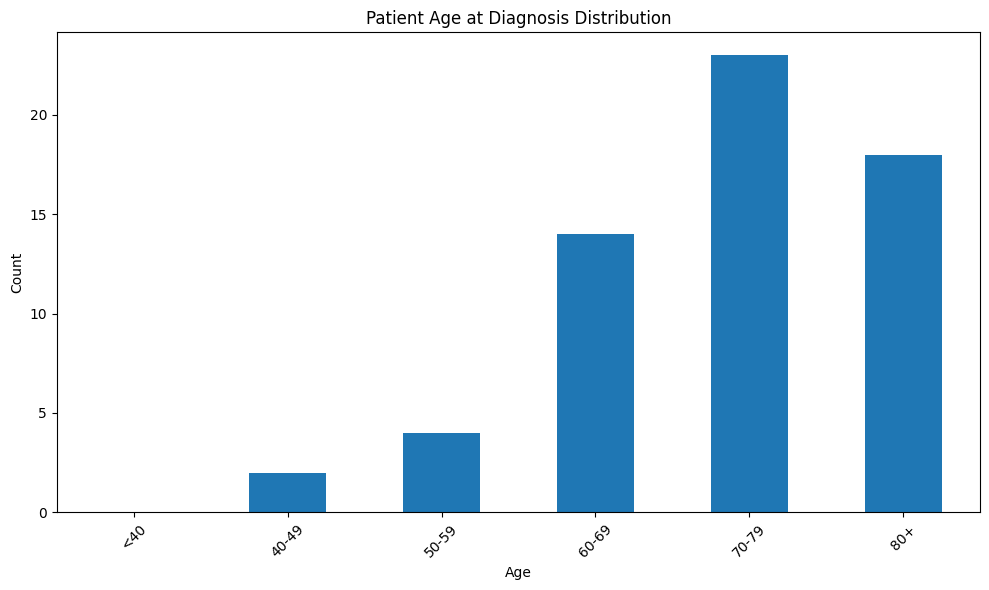

In [3]:
# patient demographics

# age
# split ages into groups
#max_age = df["Patient Age Diagnosis"].max() #might be too complicated
bins = [0, 40, 50, 60, 70, 80, 100]
labels = ["<40", "40-49", "50-59", "60-69", "70-79", "80+"]

df["Age Group"] = pd.cut(df["Patient Age Diagnosis"], bins=bins, labels=labels, right=False)

age_counts = df["Age Group"].value_counts().sort_index()

# plot
plt.figure(figsize=(10, 6))
age_counts.plot(kind="bar")

plt.title("Patient Age at Diagnosis Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

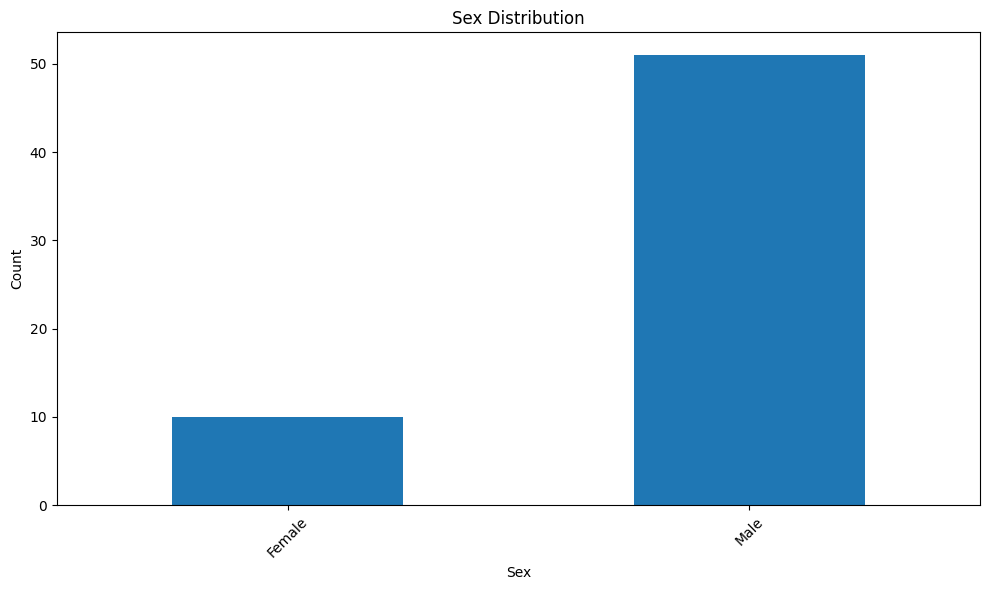

In [4]:
#sex
sex_counts = df["Sex"].value_counts().sort_index()

# plot
plt.figure(figsize=(10, 6))
sex_counts.plot(kind="bar")

plt.title("Sex Distribution")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

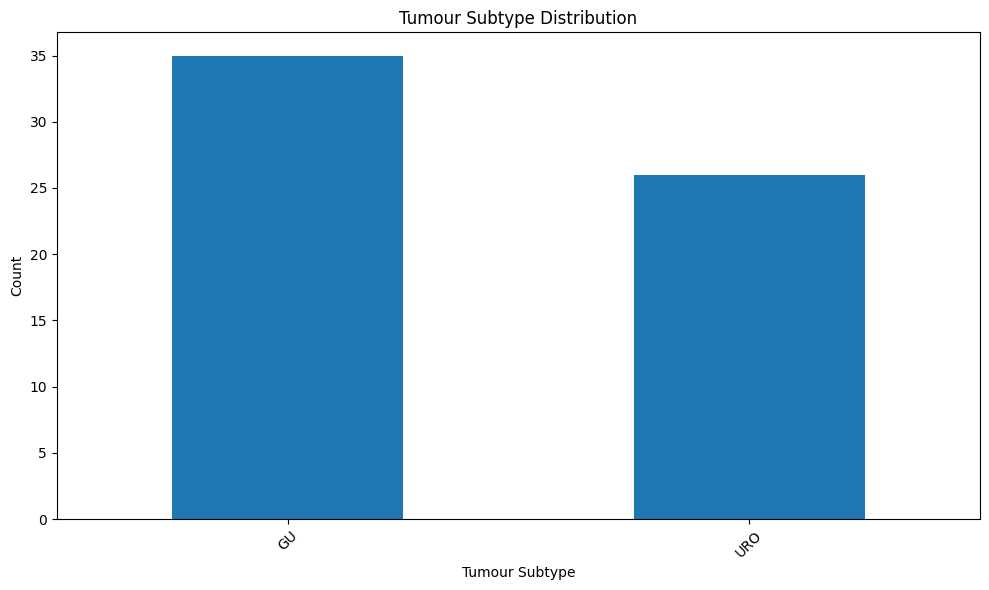

In [5]:
# tumour [statistics/insight]
# tumour subtype
subtype_counts = df["Subtype"].value_counts().sort_index()

# plot
plt.figure(figsize=(10, 6))
subtype_counts.plot(kind="bar")

plt.title("Tumour Subtype Distribution")
plt.xlabel("Tumour Subtype")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

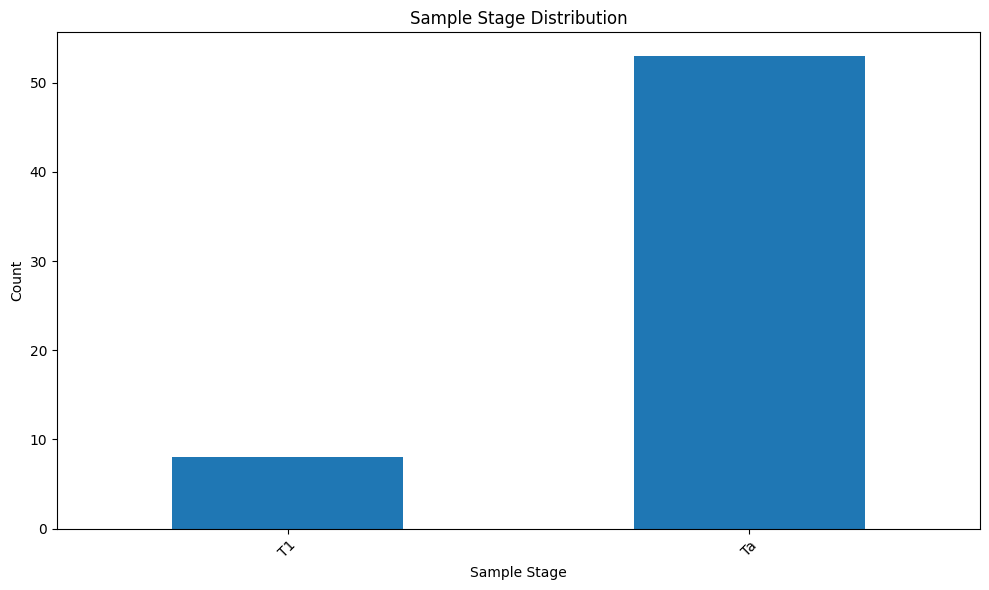

In [6]:
# sample stage
sample_stage_counts = df["Sample Stage"].value_counts().sort_index()

# plot
plt.figure(figsize=(10, 6))
sample_stage_counts.plot(kind="bar")

plt.title("Sample Stage Distribution")
plt.xlabel("Sample Stage")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

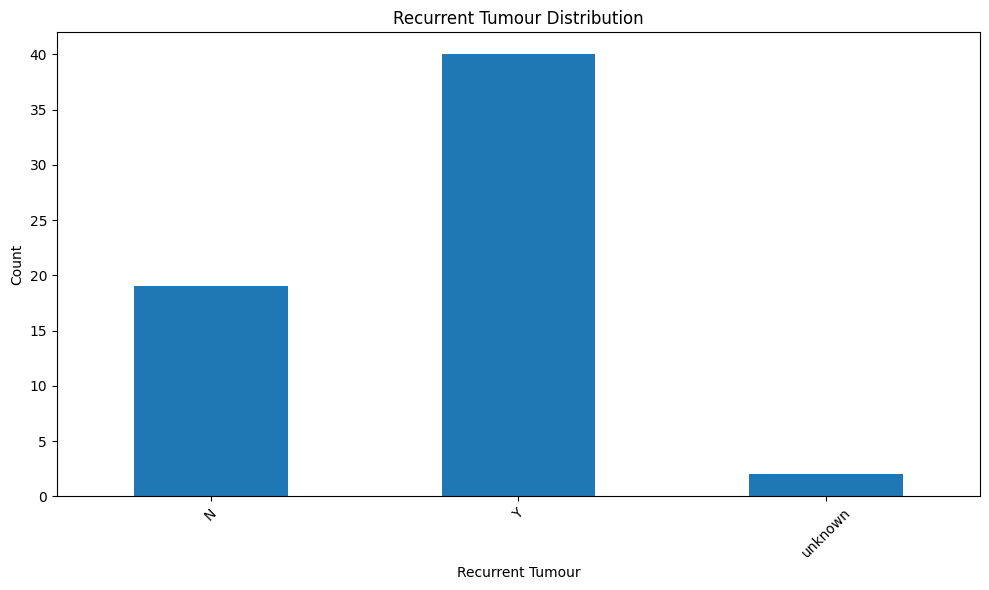

In [7]:
# recurrent tumours
sample_stage_counts = df["Recurrent Tumors"].value_counts().sort_index()

# plot
plt.figure(figsize=(10, 6))
sample_stage_counts.plot(kind="bar")

plt.title("Recurrent Tumour Distribution")
plt.xlabel("Recurrent Tumour")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Multivariate

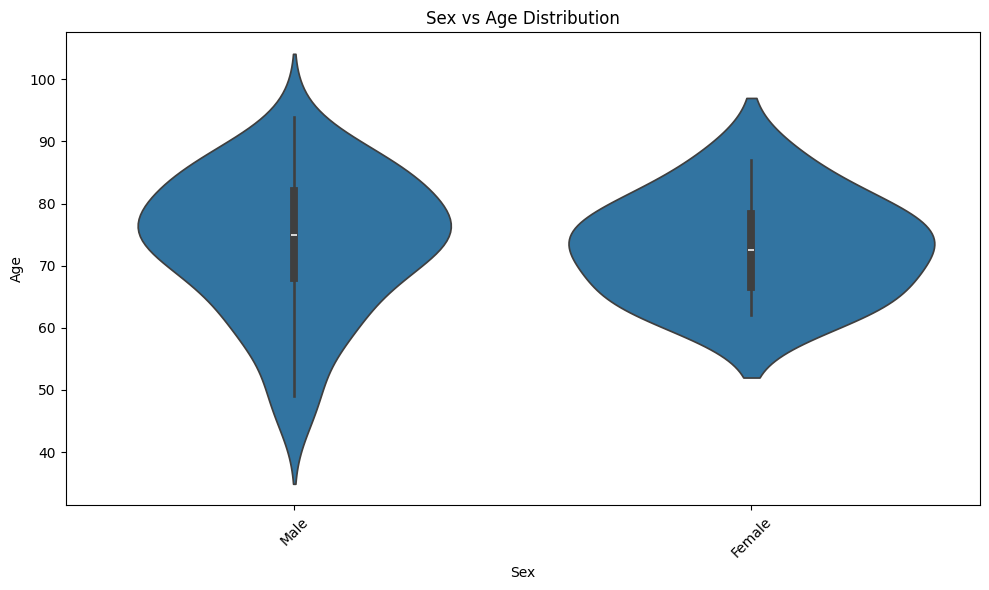

In [8]:
#age vs sex
plt.figure(figsize=(10, 6))

sns.violinplot(data=df, x="Sex", y="Patient Age Diagnosis")

plt.title("Sex vs Age Distribution")
plt.xlabel("Sex")
plt.ylabel("Age")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

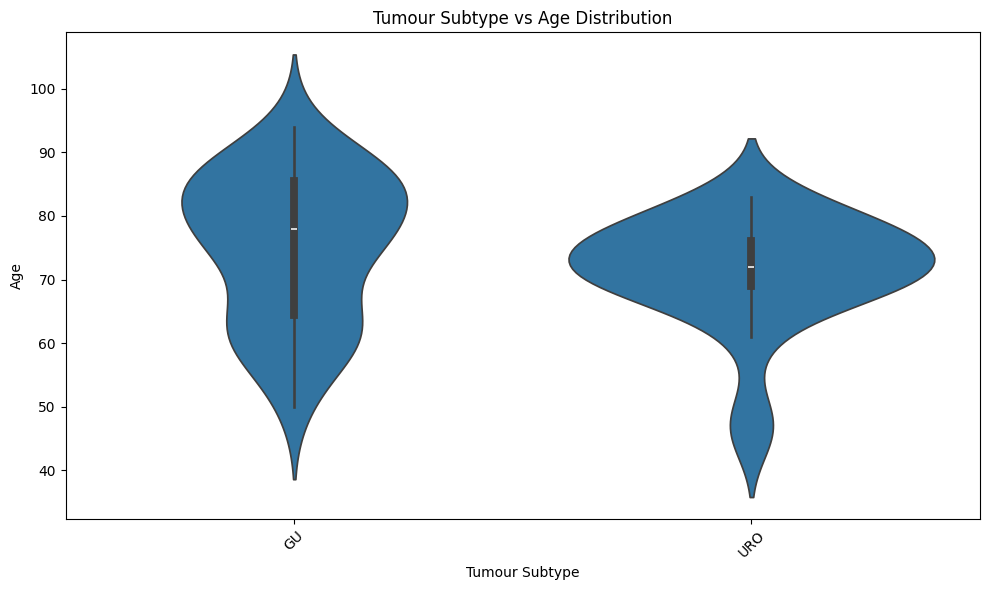

In [9]:
#tumour subtype vs age
plt.figure(figsize=(10, 6))

sns.violinplot(data=df, x="Subtype", y="Patient Age Diagnosis")

plt.title("Tumour Subtype vs Age Distribution")
plt.xlabel("Tumour Subtype")
plt.ylabel("Age")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

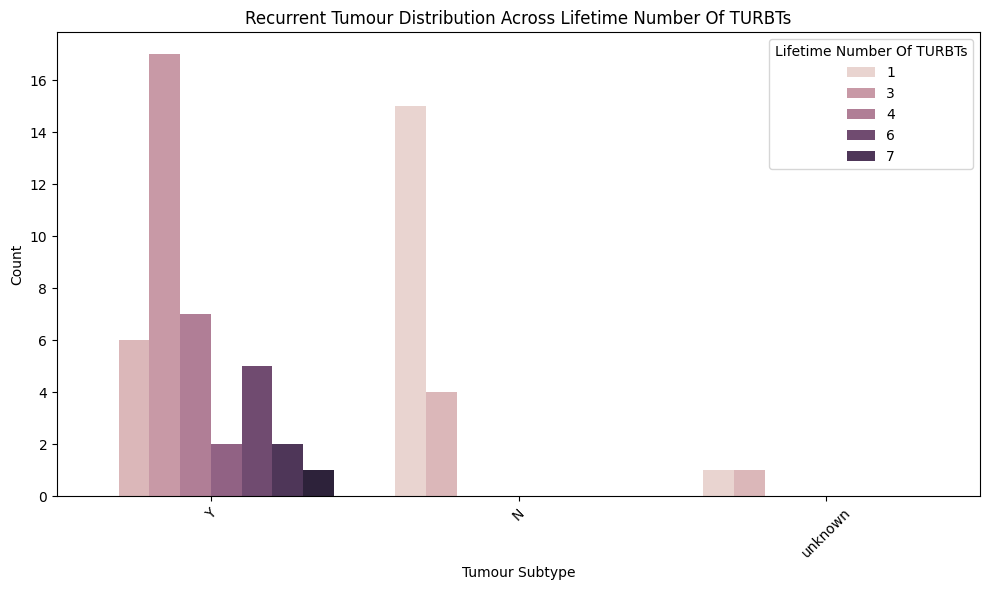

In [15]:
#tumour subtype vs gene of interest
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="Recurrent Tumors",
    hue="Lifetime Number Of TURBTs"
)


plt.title("Recurrent Tumour Distribution Across Lifetime Number Of TURBTs")
plt.xlabel("Tumour Subtype")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Analysis

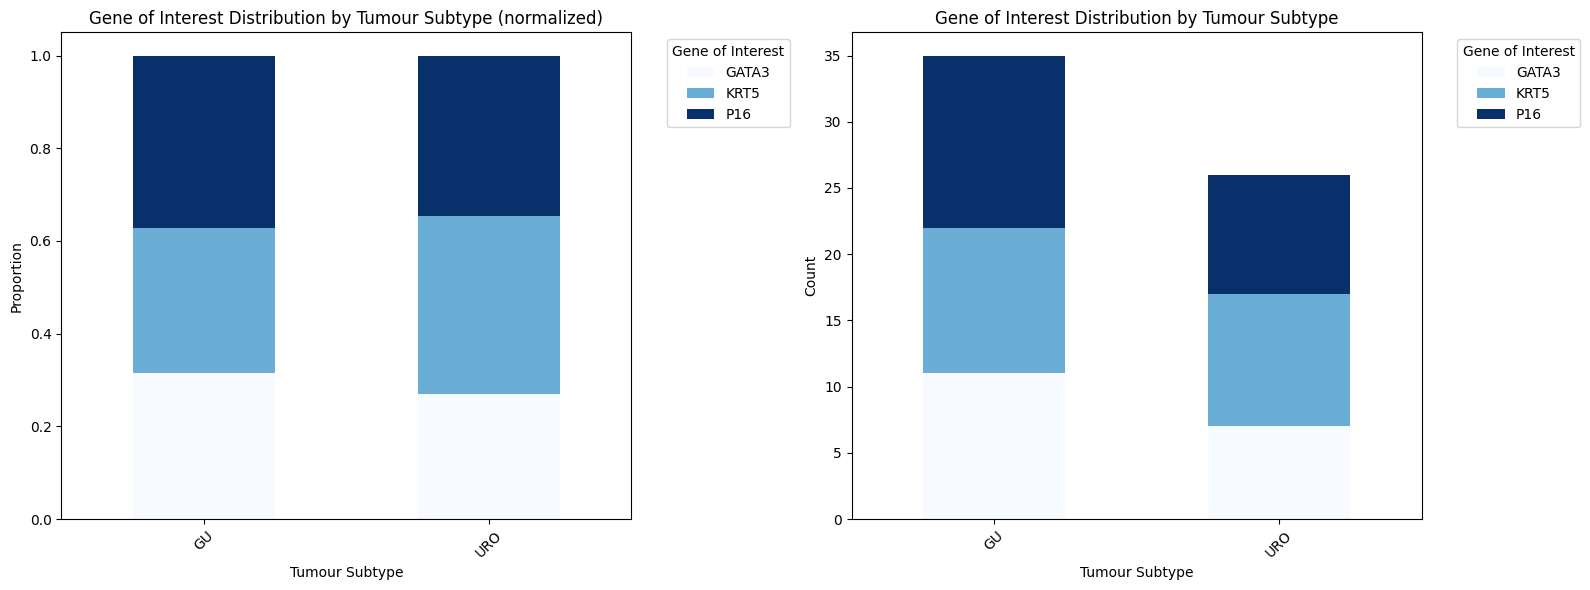

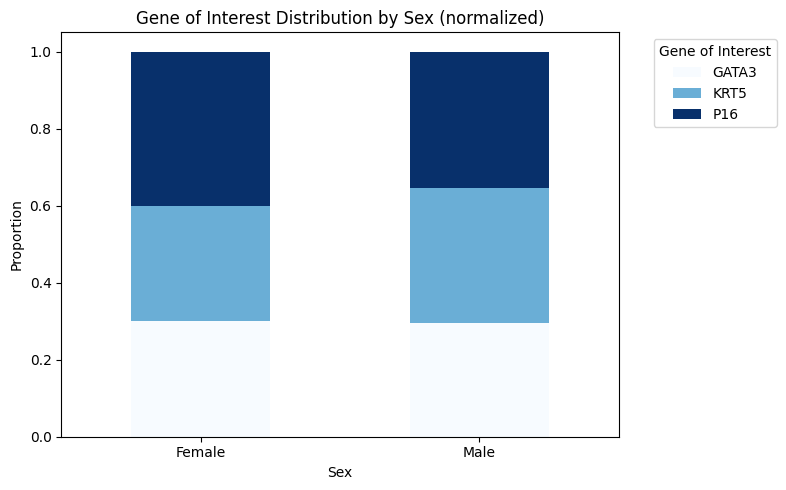

/var/folders/n4/xdczyh31799dnr6gjfnmr4l80000gn/T/ipykernel_2744/3015876109.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Gene Of Interest", y="Patient Age Diagnosis", palette="Blues")


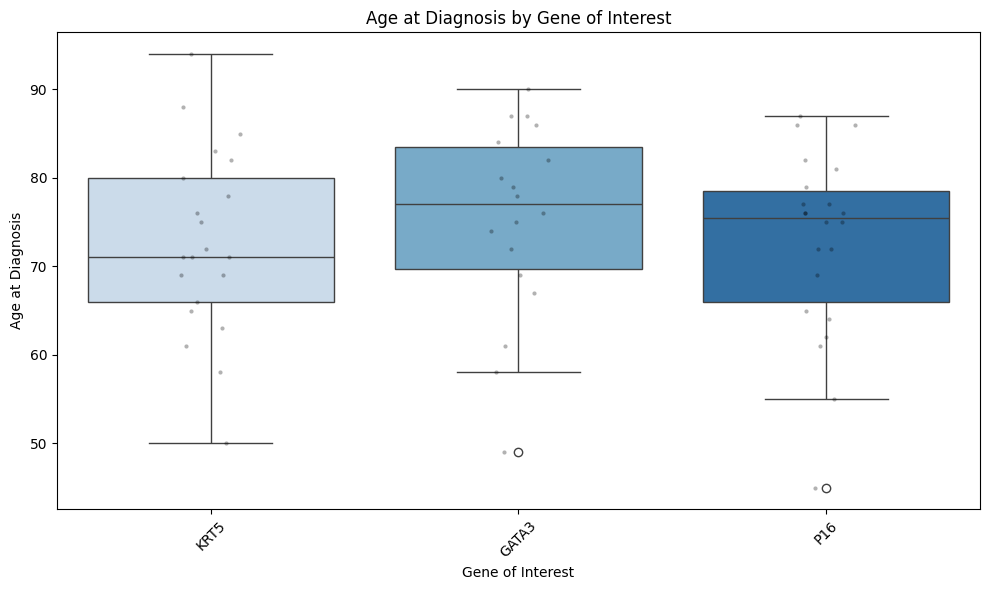

In [11]:
# Gene of Interest
 
# Gene of Interest by Tumour Subtype
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
 
ct = pd.crosstab(df["Subtype"], df["Gene Of Interest"])
ct_norm = ct.div(ct.sum(axis=1), axis=0) #normalize
 
ct_norm.plot(kind="bar", stacked=True, ax=axes[0], colormap="Blues")
axes[0].set_title("Gene of Interest Distribution by Tumour Subtype (normalized)")
axes[0].set_xlabel("Tumour Subtype")
axes[0].set_ylabel("Proportion")
axes[0].legend(title="Gene of Interest", bbox_to_anchor=(1.05, 1), loc="upper left")
axes[0].tick_params(axis="x", rotation=45)
 
# 1b. Raw counts version for comparison
ct.plot(kind="bar", stacked=True, ax=axes[1], colormap="Blues")
axes[1].set_title("Gene of Interest Distribution by Tumour Subtype")
axes[1].set_xlabel("Tumour Subtype")
axes[1].set_ylabel("Count")
axes[1].legend(title="Gene of Interest", bbox_to_anchor=(1.05, 1), loc="upper left")
axes[1].tick_params(axis="x", rotation=45)
 
plt.tight_layout()
plt.show()
 
 
# Gene of Interest by Sex
fig, ax = plt.subplots(figsize=(8, 5))
ct_sex = pd.crosstab(df["Sex"], df["Gene Of Interest"], normalize="index")
ct_sex.plot(kind="bar", stacked=True, ax=ax, colormap="Blues")
ax.set_title("Gene of Interest Distribution by Sex (normalized)")
ax.set_xlabel("Sex")
ax.set_ylabel("Proportion")
ax.legend(title="Gene of Interest", bbox_to_anchor=(1.05, 1), loc="upper left")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()
 
 
# Age distribution by Gene of Interest
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Gene Of Interest", y="Patient Age Diagnosis", palette="Blues")
sns.stripplot(data=df, x="Gene Of Interest", y="Patient Age Diagnosis",
              color="black", alpha=0.3, size=3, jitter=True)
plt.title("Age at Diagnosis by Gene of Interest")
plt.xlabel("Gene of Interest")
plt.ylabel("Age at Diagnosis")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
 

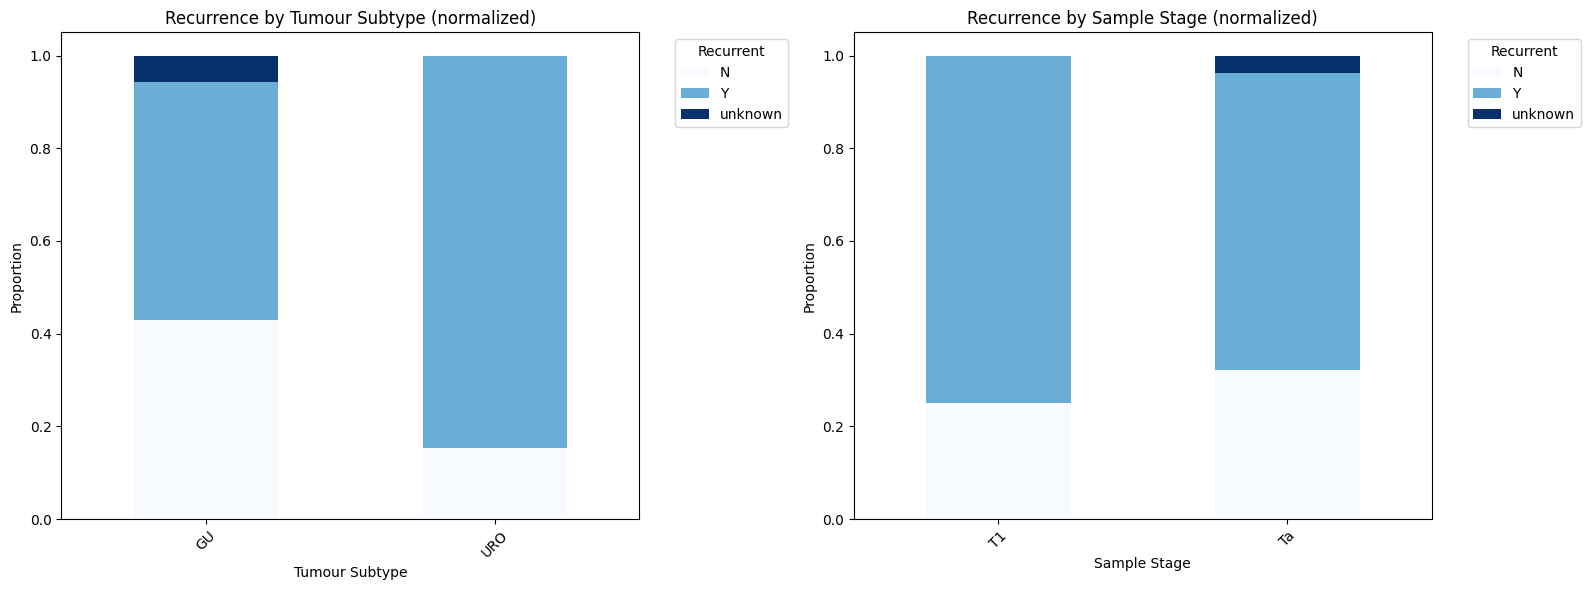

<Figure size 1000x600 with 0 Axes>

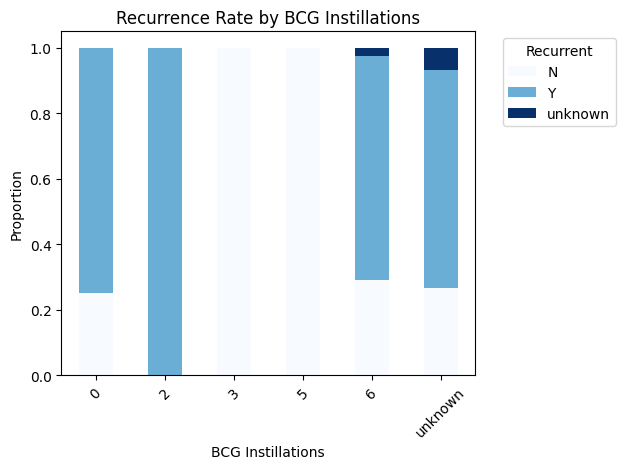

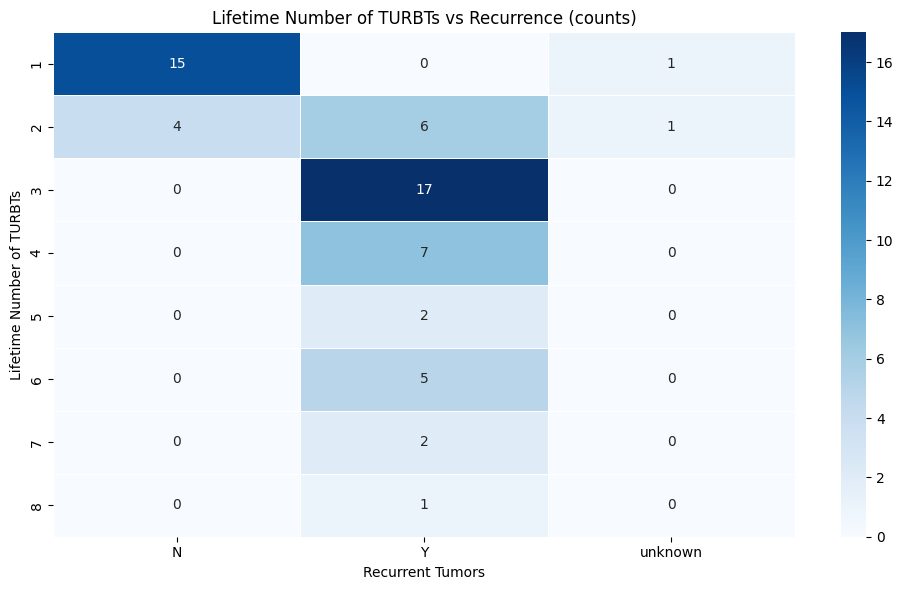

/var/folders/n4/xdczyh31799dnr6gjfnmr4l80000gn/T/ipykernel_2744/2289904657.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Recurrent Tumors", y="Patient Age Diagnosis",


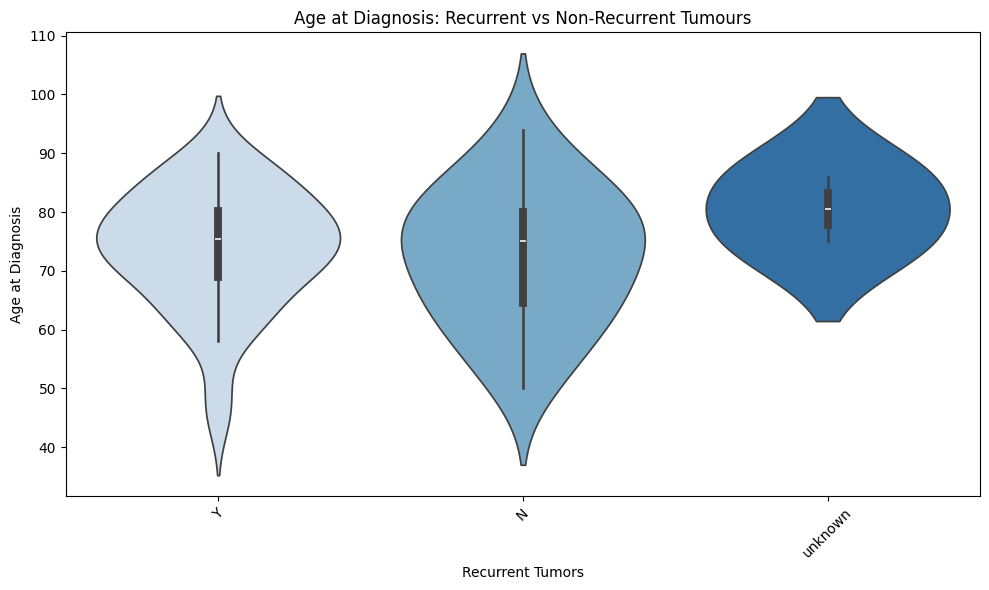

In [12]:
# Recurrence & Treatment Patterns
 
# Recurrence by Tumour Subtype
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
 
ct_rec = pd.crosstab(df["Subtype"], df["Recurrent Tumors"])
ct_rec_norm = ct_rec.div(ct_rec.sum(axis=1), axis=0)
 
ct_rec_norm.plot(kind="bar", stacked=True, ax=axes[0], colormap="Blues")
axes[0].set_title("Recurrence by Tumour Subtype (normalized)")
axes[0].set_xlabel("Tumour Subtype")
axes[0].set_ylabel("Proportion")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(title="Recurrent", bbox_to_anchor=(1.05, 1), loc="upper left")
 
# Recurrence by Stage
ct_stage_rec = pd.crosstab(df["Sample Stage"], df["Recurrent Tumors"], normalize="index")
ct_stage_rec.plot(kind="bar", stacked=True, ax=axes[1], colormap="Blues")
axes[1].set_title("Recurrence by Sample Stage (normalized)")
axes[1].set_xlabel("Sample Stage")
axes[1].set_ylabel("Proportion")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(title="Recurrent", bbox_to_anchor=(1.05, 1), loc="upper left")
 
plt.tight_layout()
plt.show()
 
 
# BCG Instillations vs Recurrence
plt.figure(figsize=(10, 6))
bcg_rec = pd.crosstab(df["BCG Instillations"], df["Recurrent Tumors"], normalize="index")
bcg_rec.plot(kind="bar", stacked=True, colormap="Blues")
plt.title("Recurrence Rate by BCG Instillations")
plt.xlabel("BCG Instillations")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.legend(title="Recurrent", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
 
 
# Lifetime TURBTs vs Recurrence (heatmap)
plt.figure(figsize=(10, 6))
turbt_rec = pd.crosstab(df["Lifetime Number Of TURBTs"], df["Recurrent Tumors"])
sns.heatmap(turbt_rec, annot=True, fmt="d", cmap="Blues", linewidths=0.5)
plt.title("Lifetime Number of TURBTs vs Recurrence (counts)")
plt.xlabel("Recurrent Tumors")
plt.ylabel("Lifetime Number of TURBTs")
plt.tight_layout()
plt.show()
 
 
# Age distribution — recurrent vs non-recurrent
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x="Recurrent Tumors", y="Patient Age Diagnosis",
               palette="Blues", inner="box")
plt.title("Age at Diagnosis: Recurrent vs Non-Recurrent Tumours")
plt.xlabel("Recurrent Tumors")
plt.ylabel("Age at Diagnosis")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

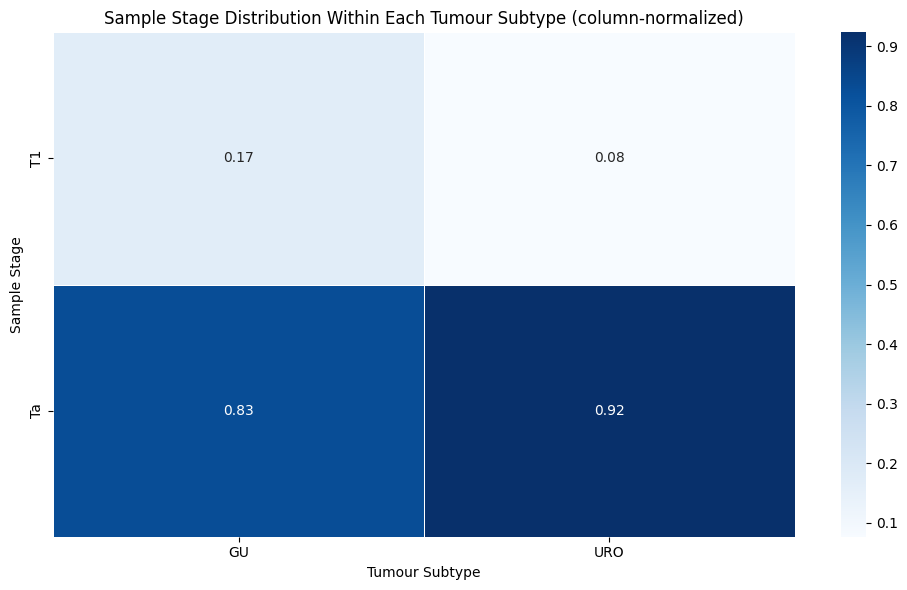

<Figure size 1000x600 with 0 Axes>

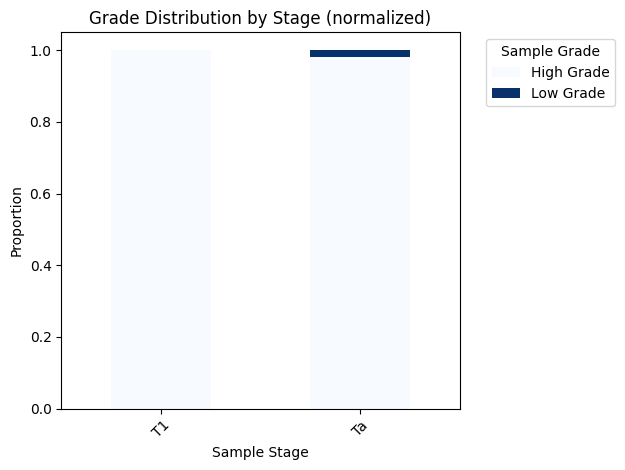

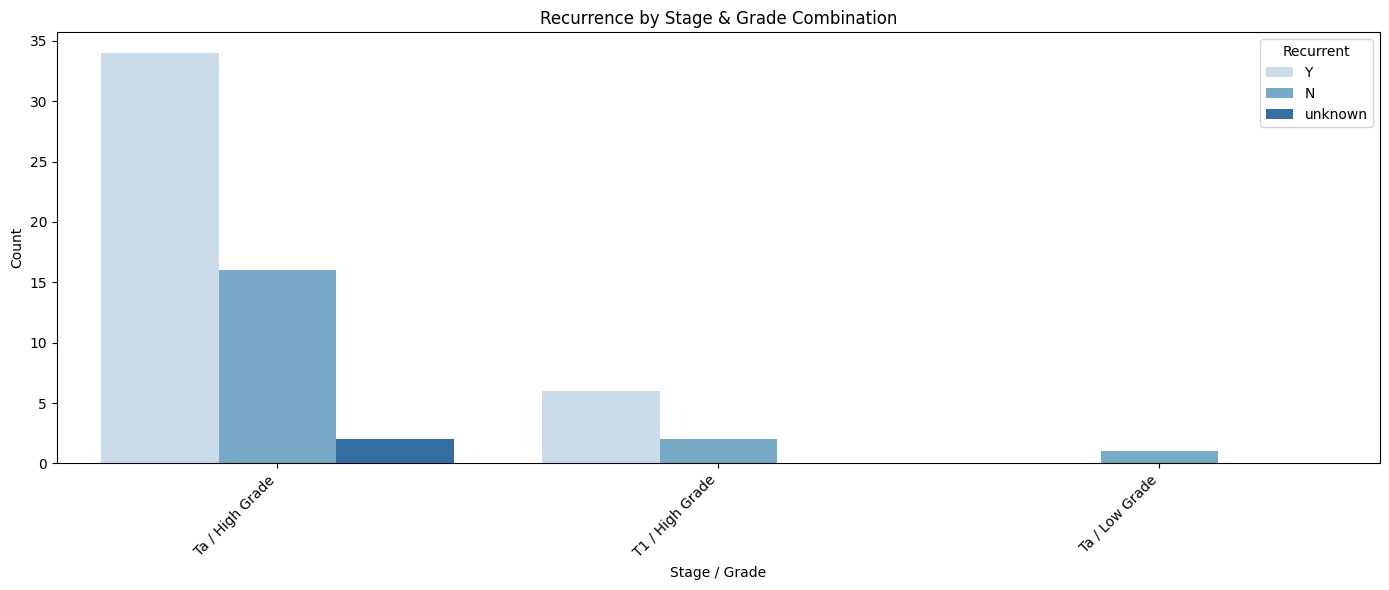

/var/folders/n4/xdczyh31799dnr6gjfnmr4l80000gn/T/ipykernel_2744/1483910288.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Sample Stage", y="Patient Age Diagnosis",


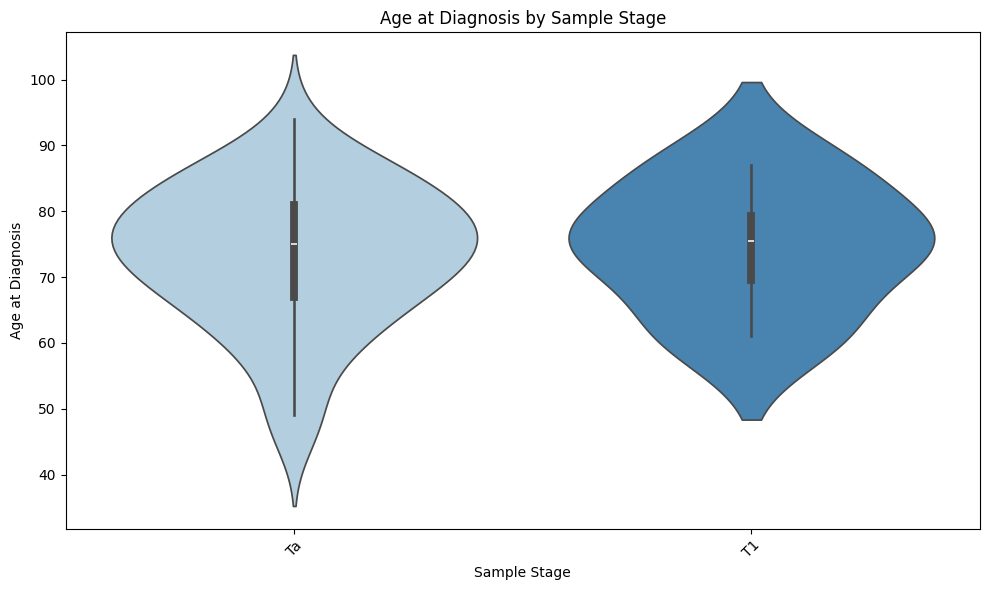

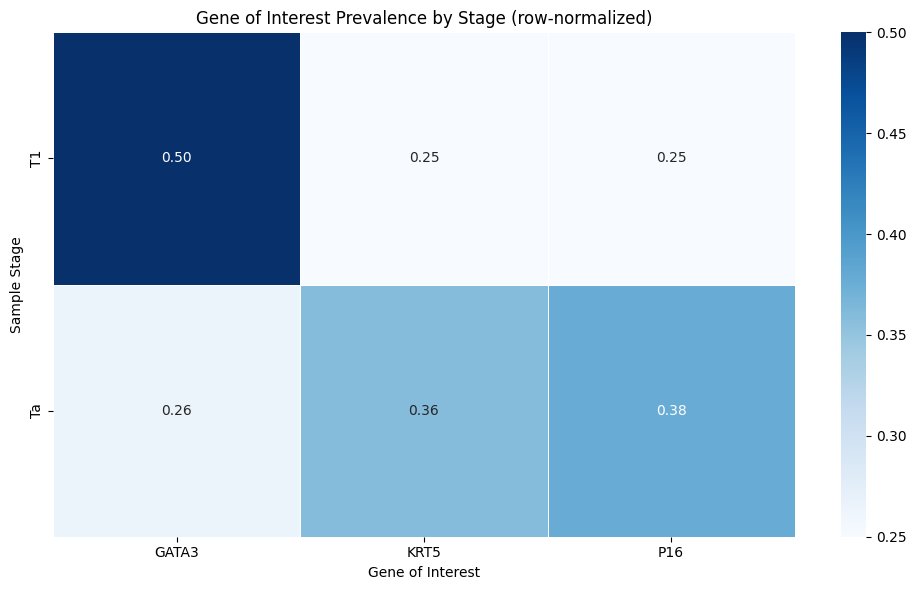

In [14]:
# Stage & Grade Relationships
 
# Stage by Subtype (heatmap) (normalized)
plt.figure(figsize=(10, 6))
stage_subtype = pd.crosstab(df["Sample Stage"], df["Subtype"], normalize="columns")
sns.heatmap(stage_subtype, annot=True, fmt=".2f", cmap="Blues", linewidths=0.5)
plt.title("Sample Stage Distribution Within Each Tumour Subtype (column-normalized)")
plt.xlabel("Tumour Subtype")
plt.ylabel("Sample Stage")
plt.tight_layout()
plt.show()
 
 
# Grade by Stage
plt.figure(figsize=(10, 6))
grade_stage = pd.crosstab(df["Sample Stage"], df["Sample Grade"], normalize="index")
grade_stage.plot(kind="bar", stacked=True, colormap="Blues")
plt.title("Grade Distribution by Stage (normalized)")
plt.xlabel("Sample Stage")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.legend(title="Sample Grade", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
 
 
# Stage & Grade vs Recurrence
df["Stage_Grade"] = df["Sample Stage"].astype(str) + " / " + df["Sample Grade"].astype(str)
plt.figure(figsize=(14, 6))
sns.countplot(
    data=df,
    x="Stage_Grade",
    hue="Recurrent Tumors",
    palette="Blues",
    order=df["Stage_Grade"].value_counts().index
)
plt.title("Recurrence by Stage & Grade Combination")
plt.xlabel("Stage / Grade")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Recurrent")
plt.tight_layout()
plt.show()
 
 
# Age by Stage
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x="Sample Stage", y="Patient Age Diagnosis",
               palette="Blues", inner="box")
plt.title("Age at Diagnosis by Sample Stage")
plt.xlabel("Sample Stage")
plt.ylabel("Age at Diagnosis")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
 
 
# Gene of Interest by Stage
plt.figure(figsize=(10, 6))
gene_stage = pd.crosstab(df["Sample Stage"], df["Gene Of Interest"], normalize="index")
sns.heatmap(gene_stage, annot=True, fmt=".2f", cmap="Blues", linewidths=0.5)
plt.title("Gene of Interest Prevalence by Stage (row-normalized)")
plt.xlabel("Gene of Interest")
plt.ylabel("Sample Stage")
plt.tight_layout()
plt.show()

### Survival Analysis
- Duration based on multiple dates

### 🔹 General Approach  
- How did you approach the challenge overall? Did you target one particular subtask over the others?

>Given the two subtasks, we decided on a divide and conquer approach. We split up the team to focus on each subtask. We ensured effective communication with regular meetings and discussions. 

- How did you divide the work to be done amongst all team members?

>We divided the work amongst team members with two members focusing on the first subtask and one member on the second. We divided up the team by our strengths, previous experience, and interests. 

- How did you make use of the resources provided (e.g. base-line code)

>The base-line code was integral to our exploration of the models and their initial performance. 

### 🔄 Task 1: Abdominal CT Image Segmentation
- What was your general **strategy** for approaching this subtask?

>Our general strategy was to run the provided baselines (unet, segresnet, swinunetr) to get a sense of their performances before going in to fine-tune the hyperparameters as well as research other models before ultimately deciding which model to focus on. 

- How did you come up with your **solution** for the subtask?

>We chose our solution based on comparison of the various model performances by looking at their dice scores. We found that segresnet performed the best among the other baseline approaches, but it was outperformed by a pretrained model of swinunetr. We ultimately decided on the pretained swinunetr model due to its stable metrics and its ability to better generalize with unseen data. 

- Did you modify/optimize the training process in any way?

>We modified/optimized the training process by updating the given parameters for the baseline. We experimented with adjusting learning rate, freezing the backbone, and enabling augmentation. We also increased the cache rate to speed up the training process.

- How did you decide to **split the data** for training? 📊

>We used an 80-20 train and validation split for the training of the model. We decide on this to ensure the model has a sufficient amount of data to train on while preventing overfitting and promoting generalization.

- Did you use any **preprocessing** or **postprocessing**? If so, what? 🔄

>We did not perform any preprocessing or postprocessing.

- **How much time did you dedicate to this task (approximately)**? ⏳

>We worked on this subtask throughout a span of 1.5 weeks, including running and fine-tuning the various models, conducting research, and collaborating in team discussions.
